<div style="text-align:left;">
  <p><em>Prepared by Latreche Sara</em></p>
</div>

<center><font size=6><b style="color:#770A7A;">Exploratory Data Analysis for Customer Churn Prediction</b></font></center>

<div style="text-align:center; margin: 20px 0;">
    <img src="./assets/churn.png" width="500" alt="Customer Retention Analytics"/>
</div>

***

**Author**: Latreche Sara  
**Date**: /2026  

### Table of Contents

- [1 | Project Overview & Context](#1-project-overview)
- [2 | Environment Setup & Data Loading](#2-setup)
- [3 | Data Integrity & Initial Inspection](#3-integrity)
- [4 | Behavioral Segmentation (Sunburst Macro View)](#4-segmentation)
- [5 | Demographic & Contractual Trend Analysis](#5-trends)
- [6 | Lifetime Value & Customer Tenure Profiling](#6-profiles)
- [7 | Categorical Factorization & Feature Correlation Matrix](#7-correlation)
- [8 | Key Analytical Insights & Preprocessing Recommendations](#8-insights)

---

## <b><a id="1-project-overview">1 <span style='color:#770A7A'>|</span> Project Overview & Context</a></b>

### The Customer Retention Challenge
In a competitive telecommunications market, acquiring a new customer is significantly more expensive than retaining an existing one. Customer churn is rarely driven by a single, isolated factor; instead, it is a complex intersection of contract structural friction, customer life stages, service tier satisfaction, and financial commitments over time. 

This notebook explores a comprehensive subscriber dataset containing thousands of historical customer records. By applying rigorous exploratory data analysis (EDA), categorical association metrics, and lifetime distribution profiling, we uncover the hidden behavioral inflection points—such as the high-risk first-year onboarding window—that drive subscriber departures. These insights serve as the direct baseline blueprint for building reliable, trustworthy predictive models to safeguard lifetime recurring revenue.

---



## <b><a id="2-setup">2 <span style='color:#770A7A'>|</span> Environment Setup & Data Loading</a></b>

To establish a reproducible environment, we initialize the data science workspace by importing primary numerical computation, statistical modeling, and data visualization libraries. The target dataset is then ingested into a structured Pandas DataFrame for preprocessing and downstream profiling.

In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , RobustScaler , OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.metrics import ( accuracy_score, 
                            precision_score, 
                            recall_score,
                            f1_score,balanced_accuracy_score,
                            confusion_matrix,roc_curve,
                            roc_auc_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB


In [12]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [5]:
df= pd.read_csv("data.csv")

## <b><a id="3-integrity">3 <span style='color:#770A7A'>|</span> Data Integrity & Initial Inspection</a></b>

Before executing statistical visualizations, we evaluate the baseline structural health of the dataset. This includes surveying structural dimensions, validating feature data types (ensuring financial figures are numeric), detecting explicit missing records, and isolating hidden empty strings that could disrupt downstream algorithms.

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
df.describe(include="all").T.style.background_gradient(cmap='YlGnBu', axis=0)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,nan,nan,nan,nan,nan,nan,nan
gender,7043,2,Male,3555,nan,nan,nan,nan,nan,nan,nan
SeniorCitizen,7043.000000,nan,nan,nan,0.162147,0.368612,0.000000,0.000000,0.000000,0.000000,1.000000
Partner,7043,2,No,3641,nan,nan,nan,nan,nan,nan,nan
Dependents,7043,2,No,4933,nan,nan,nan,nan,nan,nan,nan
tenure,7043.000000,nan,nan,nan,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
PhoneService,7043,2,Yes,6361,nan,nan,nan,nan,nan,nan,nan
MultipleLines,7043,3,No,3390,nan,nan,nan,nan,nan,nan,nan
InternetService,7043,3,Fiber optic,3096,nan,nan,nan,nan,nan,nan,nan
OnlineSecurity,7043,3,No,3498,nan,nan,nan,nan,nan,nan,nan


## <b><a id="4-segmentation">4 <span style='color:#770A7A'>|</span> Behavioral Segmentation (Sunburst Macro View)</a></b>

To observe how multiple risk factors compound simultaneously, we begin our visual discovery with a macro behavioral segmentation. By applying a multi-layered Sunburst chart, we map out hierarchical slices of our customer demographic base nested inside the wider retention pools. This structure lets us instantly isolate high-volume risk pockets across the customer ecosystem.

In [ ]:
g_labels=['Male','Female']
c_labels= ['No','Yes']


In [20]:
g_labels= ['Male','Female']
c_labels= ['No','Yes']
# create subplots use 'domain' type for Pie subplot 
fig= make_subplots(rows=1,cols=2,specs=[[{'type':'domain'},{'type':'domain'}]])
fig.add_trace(go.Pie(labels=g_labels,values=df['gender'].value_counts(),name='Gender',hole=0.4,),1,1)
fig.add_trace(go.Pie(labels=c_labels,values=df['Churn'].value_counts(),name='Gender',hole=0.4,),1,2)
fig.update_layout(
    title_text="Gender and Churn Distributions",
    # add anotations in the center of donut charts 
    annotations=[dict(text='Gender', x=0.16, y=0.5, font_size=20, showarrow=False),
                 dict(text='Churn', x=0.84, y=0.5, font_size=20, showarrow=False)])
fig.show()


In [21]:
df.groupby("gender")["Churn"].value_counts()

gender  Churn
Female  No       2549
        Yes       939
Male    No       2625
        Yes       930
Name: count, dtype: int64

In [32]:

# Define data
labels = ["Churn: Yes", "Churn: No", "F_Yes", "M_Yes", "F_No", "M_No"]
parents = ["", "", "Churn: Yes", "Churn: Yes", "Churn: No", "Churn: No"]
values = [1869, 5163, 939, 930, 2544, 2619]

# --- CORRECT COLOR MAPPING ---
# Create a dictionary where each data label maps to a specific color
# Use logic: similar parent (No/Yes) = similar outer color family
color_map = {
    # Innermost rings (Parent categories)
    "Churn: No":"firebrick",   # Total 'No Churn' (blue family)
    "Churn: Yes":"royalblue", # Total 'Yes Churn' (red family)

    # Outer rings (Children) - linked to parent colors
    # No Churn branch (royalblue shades)
    "F_No": "tomato" , 
    "M_No": "salmon",

    # Yes Churn branch (firebrick shades)
    "F_Yes": "deepskyblue",
    "M_Yes":"skyblue" 
}

# Create a color array matching the 'labels' list, mapping from the dictionary
# This ensures that "labels[0]" color is in "colors[0]"
colors_array = [color_map[label] for label in labels]

# --- CREATE CHART ---
fig = go.Figure(go.Sunburst(
    labels=labels,
    parents=parents,
    values=values,
    branchvalues="total",
    
    # Customizing what text displays inside the slices
    textinfo="label+percent parent", 
    
    # Apply the correct color sequence to the data
    marker=dict(colors=colors_array),
))

# Define layout with a clean template
fig.update_layout(
    title="Churn Distribution w.r.t Gender",
    width=600,
    height=600,
    template="plotly_white", # Provides a clean white background
)

fig.show()

## <b><a id="5-trends">5 <span style='color:#770A7A'>|</span> Demographic & Contractual Trend Analysis</a></b>

Building upon our macro behavioral discoveries, we isolate the specific relationships between demographic status and structural commitment terms. Using grouped proportion bar charts, we inspect how the presence or absence of dependents alters subscription stability when interacting with Month-to-month, One-year, and Two-year contracts.

In [33]:
fig = px.histogram(df, x="Churn", color="Contract", barmode="group", title="<b>Customer contract distribution<b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [40]:
# Plotly Express automatically counts rows and aligns labels perfectly
fig = px.pie(
    df, 
    names='PaymentMethod', 
    hole=0.3, 
    title="<b>Payment Method Distribution</b>"
)

fig.show()

In [43]:
fig = px.histogram(df, x="Churn", color="PaymentMethod", title="<b>Customer Payment Method distribution w.r.t. Churn</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

Major customers who moved out were having Electronic Check as Payment Method.
Customers who opted for Credit-Card automatic transfer or Bank Automatic Transfer and Mailed Check as Payment Method were less likely to move out.

In [48]:
df["InternetService"].unique()


array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [ ]:
df[df["gender"]=="Male"][["InternetService", "Churn"]].value_counts()


InternetService  Churn
DSL              No       993
Fiber optic      No       910
No               No       722
Fiber optic      Yes      633
DSL              Yes      240
No               Yes       57
Name: count, dtype: int64

In [50]:
df[df["gender"]=="Male"][["InternetService", "Churn"]].value_counts()


InternetService  Churn
DSL              No       993
Fiber optic      No       910
No               No       722
Fiber optic      Yes      633
DSL              Yes      240
No               Yes       57
Name: count, dtype: int64

In [54]:
df[df["gender"]=="Female"][["InternetService", "Churn"]].value_counts()


InternetService  Churn
DSL              No       969
Fiber optic      No       889
No               No       691
Fiber optic      Yes      664
DSL              Yes      219
No               Yes       56
Name: count, dtype: int64

In [53]:
fig = go.Figure()

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [965, 992, 219, 240],
  name = 'DSL',
))

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [889, 910, 664, 633],
  name = 'Fiber optic',
))

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [690, 717, 56, 57],
  name = 'No Internet',
))

fig.update_layout(title_text="<b>Churn Distribution w.r.t. Internet Service and Gender</b>")

fig.show()

A lot of customers choose the Fiber optic service and it's also evident that the customers who use Fiber optic have high churn rate, this might suggest a dissatisfaction with this type of internet service.
Customers having DSL service are majority in number and have less churn rate compared to Fibre optic service.


## <b><a id="5-trends">5 <span style='color:#770A7A'>|</span> Demographic & Contractual Trend Analysis</a></b>

Building upon our macro behavioral discoveries, we isolate the specific relationships between demographic status and structural commitment terms. Using grouped proportion bar charts, we inspect how the presence or absence of dependents alters subscription stability when interacting with Month-to-month, One-year, and Two-year contracts.

In [59]:
#color_map = {"Yes": "#FF97FF", "No": "#AB63FA"}
fig = px.histogram(df, x="Churn", color="Dependents", barmode="group", title="<b>Dependents distribution</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [65]:

# 1. Prepare data by resetting index so columns are accessible
plot_df = df.groupby(["Dependents", "Contract"])["Churn"].value_counts(normalize=True).rename("Percentage").reset_index()
plot_df["Percentage"] *= 100  # Convert fractions to clean percentages

# 2. Build the clustered bar chart
fig = px.bar(
    plot_df,
    x="Contract",
    y="Percentage",
    color="Churn",
    facet_col="Dependents",
    barmode="group",
    title="<b>Churn Rates by Contract Type and Dependent Status</b>",
    labels={"Percentage": "Percentage (%)"},
    color_discrete_map={"Yes": "firebrick", "No": "royalblue"} # Match your color theme
)

fig.update_layout(yaxis_ticksuffix="%")
fig.show()

Customers without dependents are indeed more likely to churn, but it heavily depends on whether they are on a Month-to-month contract. Lacking dependents acts as a risk amplifier specifically for flexible, short-term accounts. When a customer is single/without dependents and has zero contract friction to leave, they hit the highest risk profile in your entire dataset (45% churn). If they have a family, even a month-to-month account stays notably more stable ("stickier"), likely due to the high domestic disruption cost of changing service providers.

In [66]:
fig = px.histogram(df, x="Churn", color="Partner", barmode="group", title="<b>Chrun distribution w.r.t. Partners</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

Customers that doesn't have partners are more likely to churn


In [67]:

fig = px.histogram(df, x="Churn", color="SeniorCitizen", title="<b>Chrun distribution w.r.t. Senior Citizen</b>")
fig.show()

It can be observed that the fraction of senior citizen is very less.
Most of the senior citizens churn.

In [68]:
fig = px.histogram(df, x="Churn", color="OnlineSecurity", barmode="group", title="<b>Churn w.r.t Online Security</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

Most customers churn in the absence of online security,


In [69]:
fig = px.histogram(df, x="Churn", color="PaperlessBilling",  title="<b>Chrun distribution w.r.t. Paperless Billing</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

Customers with Paperless Billing are most likely to churn.


In [70]:
fig = px.histogram(df, x="Churn", color="TechSupport",barmode="group",  title="<b>Chrun distribution w.r.t. TechSupport</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

Customers with no TechSupport are most likely to migrate to another service provider.


In [72]:
fig = px.histogram(df, x="Churn", color="PhoneService", title="<b>Chrun distribution w.r.t. Phone Service</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

Very small fraction of customers don't have a phone service and out of that, 1/3rd Customers are more likely to churn.


## <b><a id="6-profiles">6 <span style='color:#770A7A'>|</span> Lifetime Value & Customer Tenure Profiling</a></b>

To bridge behavioral choices with explicit timelines and monetary metrics, this section explores continuous distributions. By plotting Kernel Density Estimate (KDE) curves for accumulated financial charges and pairing them with boxplots mapping subscriber tenure, we isolate the exact operational "critical windows" where attrition peaks during the user lifecycle.

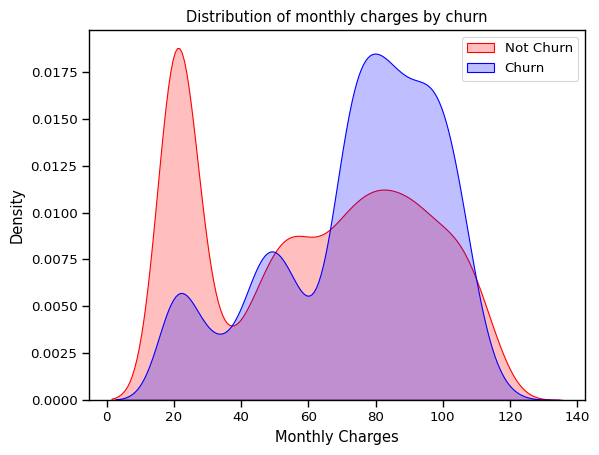

In [74]:
sns.set_context("paper",font_scale=1.1)
ax = sns.kdeplot(df.MonthlyCharges[(df["Churn"] == 'No') ],
                color="Red", fill=True);
ax = sns.kdeplot(df.MonthlyCharges[(df["Churn"] == 'Yes') ],
                ax =ax, color="Blue", fill=True);
ax.legend(["Not Churn","Churn"],loc='upper right');
ax.set_ylabel('Density');
ax.set_xlabel('Monthly Charges');
ax.set_title('Distribution of monthly charges by churn');

Customers with higher Monthly Charges are also more likely to churn


In [76]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

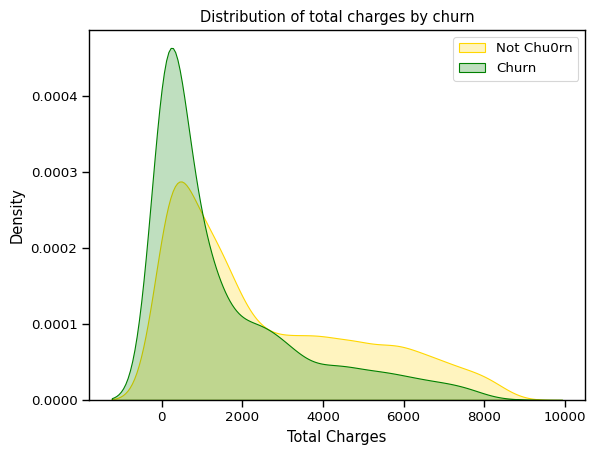

In [78]:
ax = sns.kdeplot(df.TotalCharges[(df["Churn"] == 'No') ],
                color="Gold", fill=True);
ax = sns.kdeplot(df.TotalCharges[(df["Churn"] == 'Yes') ],
                ax =ax, color="Green", fill=True);
ax.legend(["Not Chu0rn","Churn"],loc='upper right');
ax.set_ylabel('Density');
ax.set_xlabel('Total Charges');
ax.set_title('Distribution of total charges by churn');

While it is easy to assume that "cheap accounts churn more," remember to cross-reference this with your previous plot about Contract Types!

Total charges are a function of two things: monthly rate and tenure (how many months they've stayed). Because we already know that Month-to-month contracts have a massive 45% churn rate, what you are actually seeing here is likely the exact same phenomenon: new, short-term month-to-month users leaving after only 1 to 3 months of service, before they ever have a chance to build up high total charges.

In [79]:
fig = px.box(df, x='Churn', y = 'tenure')

# Update yaxis properties
fig.update_yaxes(title_text='Tenure (Months)', row=1, col=1)
# Update xaxis properties
fig.update_xaxes(title_text='Churn', row=1, col=1)

# Update size and title
fig.update_layout(autosize=True, width=750, height=600,
    title_font=dict(size=25, family='Courier'),
    title='<b>Tenure vs Churn</b>',
)

fig.show()


## <b><a id="7-correlation">7 <span style='color:#770A7A'>|</span> Categorical Factorization & Feature Correlation Matrix</a></b>

To wrap up visual data exploration, we translate our individual categorical insights into a unified mathematical grid. By factorizing categorical values into sequential labels and applying an upper-triangle mask to a Pearson correlation matrix heatmap, we screen for strong linear linkages, hidden dependencies, and potential multicollinearity anomalies (such as artificial tracking identifiers or overlapping service add-ons).

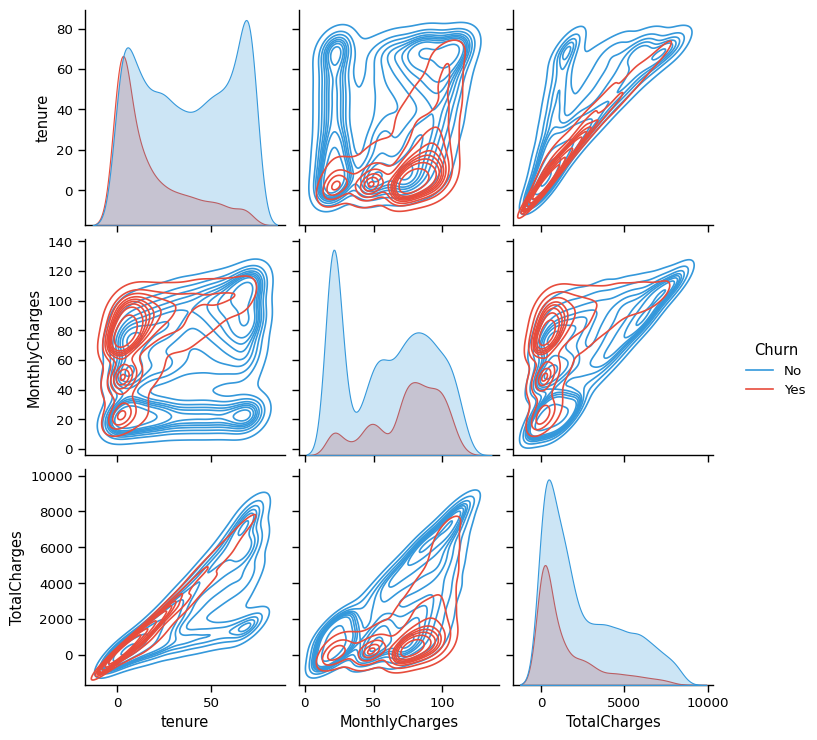

In [81]:
# Select only numeric columns + your categorical target
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']

# Run pairplot with KDE curves instead of scatterplots
sns.pairplot(
    df[numeric_cols], 
    hue='Churn', 
    kind='kde', 
    palette={'Yes': '#e74c3c', 'No': '#3498db'}
)
plt.show()

The Demographics/Contracts: Single people without dependents heavily favor volatile Month-to-month contracts.

The Timeline (This Plot): Because of that lack of contractual lock-in, they exit rapidly during their first 10 months of service.

The Financials (Previous Plot): Because they leave so early in their lifecycle, they create that massive spike of low Total Charges between $0 and $1,500 that you saw on the density curve.

You have isolated a highly specific operational target: the first year of customer onboarding. Any retention campaigns or incentives should be targeted squarely at keeping users engaged during their first 12 months to get them across that "risk valley."

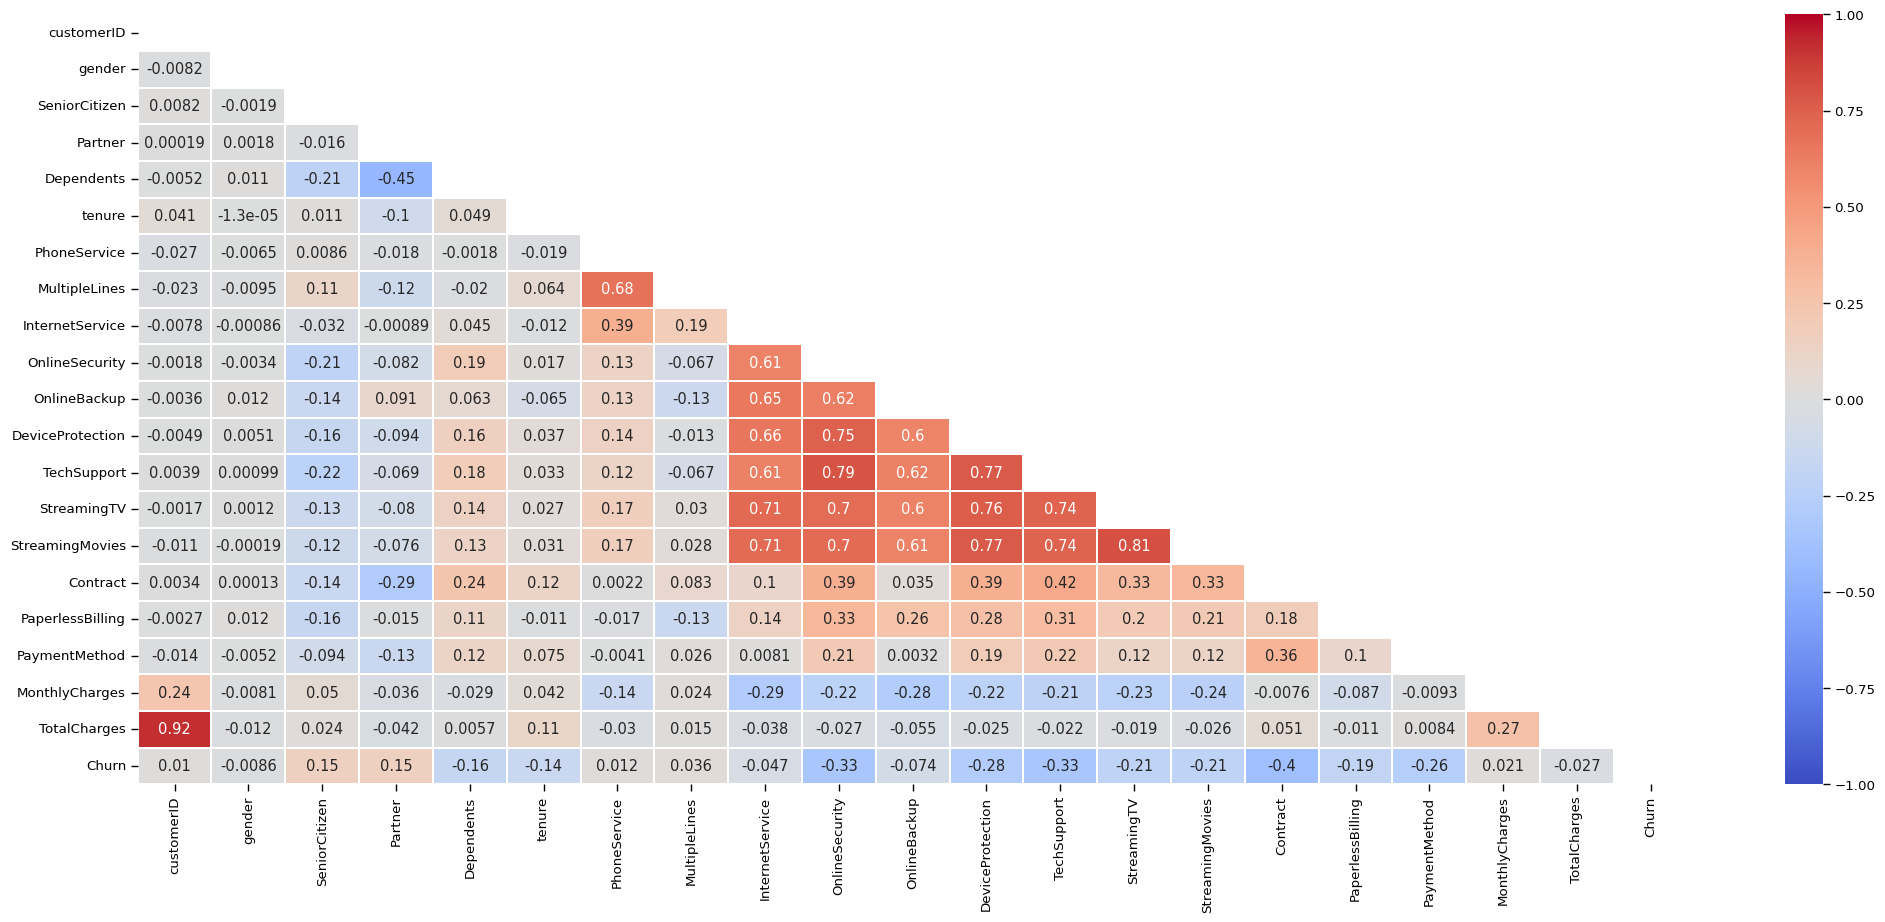

In [80]:
plt.figure(figsize=(25, 10))

corr = df.apply(lambda x: pd.factorize(x)[0]).corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

ax = sns.heatmap(corr, mask=mask, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, linewidths=.2, cmap='coolwarm', vmin=-1, vmax=1)

## <b><a id="8-insights">8 <span style='color:#770A7A'>|</span> Key Analytical Insights & Preprocessing Recommendations</a></b>

Based on our exploratory roadmap, we finalize our core behavioral findings and outline the specific preprocessing requirements—including missing-value imputation for hidden spaces, strategic feature engineering of collinear variables, and scaling operations—necessary to optimize dataset preparation for predictive model training.